<a href="https://colab.research.google.com/github/anilkumargangadhara09/GenAI-ML/blob/main/Anil_NLP_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import required libs
##

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load train and test data

In [2]:
# data loading train and test

try:
    train_df = pd.read_csv('/content/train_tweet.csv', encoding='latin-1', header=0)
    test_df = pd.read_csv('/content/test_tweets.csv', encoding='latin-1', header=0)

    if train_df.empty or test_df.empty :
        print("The Data is empty. Please check the file contents.")
        exit()
    if 'train_df' in locals() or 'train_df' in globals() and 'test_df' in locals() or 'test_df' in globals():
        print("Data loaded successfully.")
        # Display the first few rows to verify
        display(train_df.head(5))
        # display(test_df.head(2))
    else:
        print("Failed to load the Data.")

except FileNotFoundError:
    print("File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")
    exit()

Data loaded successfully.


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [3]:
test_df.head(5)

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [4]:
print(train_df.shape)
print(test_df.shape)

(31962, 3)
(17197, 2)


## Exploratory data analysis

In [5]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17197 entries, 0 to 17196
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      17197 non-null  int64 
 1   tweet   17197 non-null  object
dtypes: int64(1), object(1)
memory usage: 268.8+ KB


In [6]:
train_df.describe()
# test_df.describe()

,id,label
count,31962.000000,31962.000000
mean,15981.500000,0.070146
std,9226.778988,0.255397
min,1.000000,0.000000
25%,7991.250000,0.000000
50%,15981.500000,0.000000
75%,23971.750000,0.000000
max,31962.000000,1.000000


In [7]:
print(f'train df null: \n', train_df.isnull().any())
print(f'test df null: \n', test_df.isnull().any())

train df null: 
 id       False
label    False
tweet    False
dtype: bool
test df null: 
 id       False
tweet    False
dtype: bool


In [8]:
# checking out the postive comments from the train set

train_df[train_df['label'] == 1].head(5)

,id,label,tweet
13,14,1,@user #cnn calls #michigan middle school 'buil...
14,15,1,no comment! in #australia #opkillingbay #se...
17,18,1,retweet if you agree!
23,24,1,@user @user lumpy says i am a . prove it lumpy.
34,35,1,it's unbelievable that in the 21st century we'...


In [9]:
# checking out the negative comments from the train set

train_df[train_df['label'] == 0].head(5)

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## The distribution of tweet

<Axes: xlabel='label'>

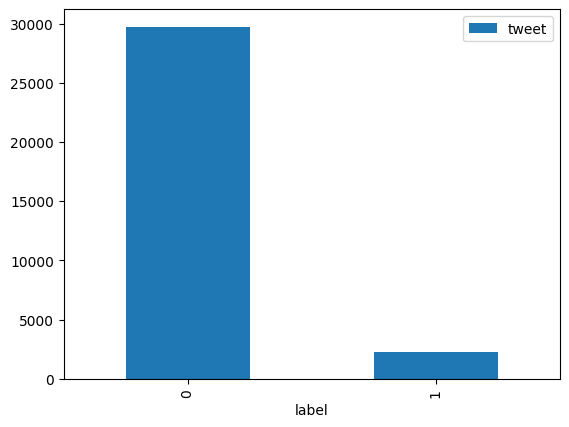

In [10]:
# values count
train_df['label'].value_counts()

# The distribution of sentiments
train_df[['label', 'tweet']].groupby('label').count().plot(kind='bar')

<Axes: ylabel='Frequency'>

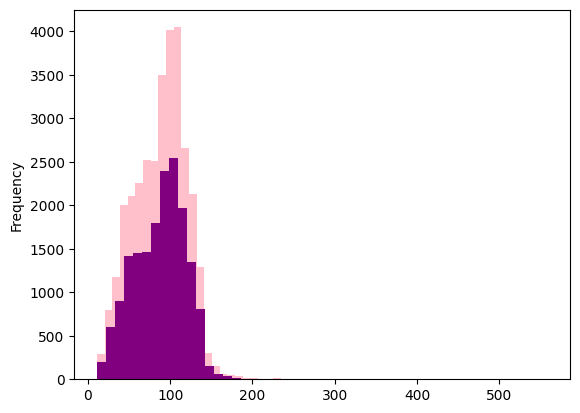

In [11]:
train_df['tweet'].str.len().plot(kind='hist', bins=50, color='pink')
test_df['tweet'].str.len().plot(kind='hist', bins=50, color='purple')

   label  count
0      0  29720
1      1   2242


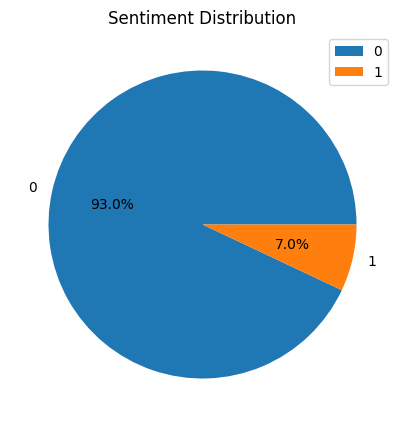

In [12]:
df_label = train_df.label.value_counts().reset_index()

print(df_label)
plt.figure(figsize=(5,5))
plt.pie(df_label['count'], labels=df_label['label'], autopct='%1.1f%%')
plt.legend()
plt.title('Sentiment Distribution')
plt.show()

## Feature Extraction

In [13]:
# Feature engineering
# adding a column to represent the length of the tweet
train_df['tweet_len'] = train_df['tweet'].apply(len)
test_df['tweet_len'] = test_df['tweet'].apply(len)

train_df.head(5)

,id,label,tweet,tweet_len
0,1,0,@user when a father is dysfunctional and is s...,102
1,2,0,@user @user thanks for #lyft credit i can't us...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,118
4,5,0,factsguide: society now #motivation,39


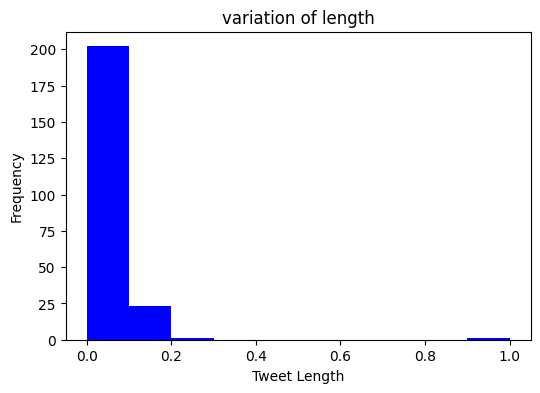

In [14]:
train_df.groupby('tweet_len')['label'].mean().plot.hist(color='blue', figsize=(6,4))
# train_df.groupby('len').mean()['label'].plot.hist(color = 'black', figsize = (6, 4),)
plt.xlabel('Tweet Length')
# plt.ylabel('Mean Label')
plt.title('variation of length')
plt.show()

 **Count Vectorizer**:
CountVectorizer is a text preprocessing technique commonly used in natural language processing (NLP) tasks for converting a collection of text documents into a numerical representation. It is part of the scikit-learn library

**Why:** Vectorization is needed because machine learning models work with numbers, not text. To analyze, classify, or make predictions based on text data, the text must first be transformed into a numerical form that these models can process.



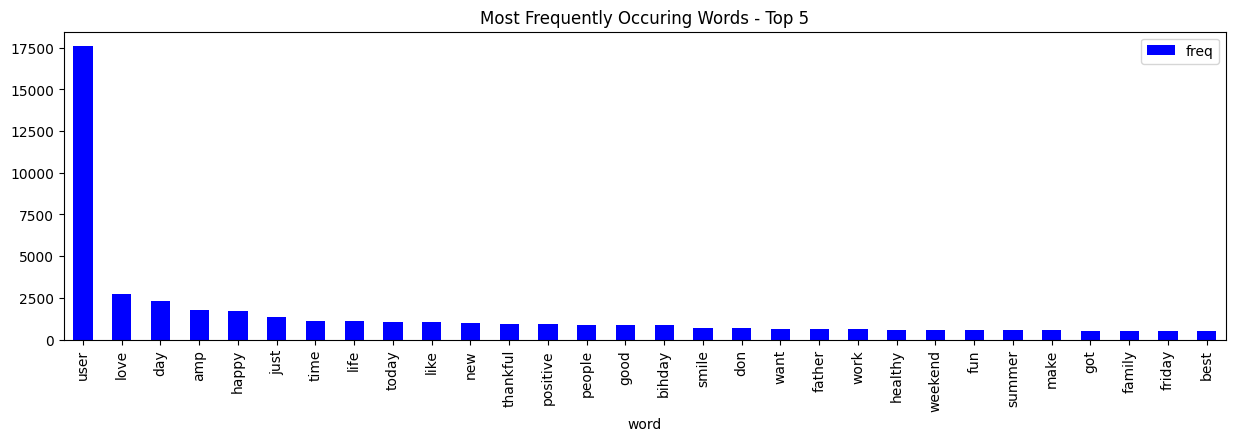

In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Convert a collection of text documents to a matrix of token counts.
# Create an instance of CountVectorizer
cv = CountVectorizer(stop_words='english', lowercase=False)

words = cv.fit_transform(train_df['tweet'])

# print(words)

sum_words = words.sum(axis=0)
# print(sum_words)

words_freq = [(word, sum_words[0, i]) for word, i in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

frequency = pd.DataFrame(words_freq, columns=['word', 'freq'])

frequency.head(30).plot(x='word', y='freq', kind='bar', figsize=(15, 4), color='blue')
plt.title("Most Frequently Occuring Words - Top 5")
plt.show()



**Word Cloud**

Wordcloud is the pictorial representation of the word frequency of the dataset.WordCloud is easier to understand and gives a better idea about our textual data

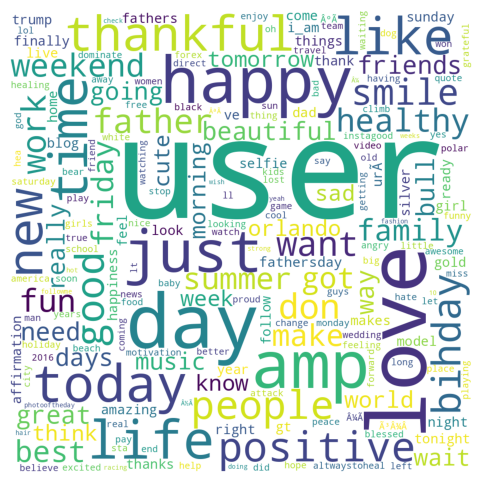

In [16]:
from wordcloud import WordCloud

wordcloud = WordCloud(background_color = 'white', width = 1000, height = 1000).generate_from_frequencies(dict(words_freq))

plt.figure(figsize=(8,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()